Phase 3 --> NLP Precessing 

Libraries imported successfully!


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hassa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hassa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hassa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hassa\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


NLTK resources downloaded successfully!
Dataset loaded successfully!
NLP tools initialized successfully!
Text preprocessing completed successfully!

ORIGINAL TEXT:

i feel so sad today

PROCESSED TEXT:

feel sad today

ORIGINAL TEXT:

i can't stop crying

PROCESSED TEXT:

cant stop cry

ORIGINAL TEXT:

i feel empty inside

PROCESSED TEXT:

feel empty inside

ORIGINAL TEXT:

nothing makes me happy anymore

PROCESSED TEXT:

nothing make happy anymore

ORIGINAL TEXT:

i feel so anxious

PROCESSED TEXT:

feel anxious
Number of Empty Processed Rows:
0
Processed Text Length:
count    49.000000
mean     15.775510
std       5.572497
min       4.000000
25%      11.000000
50%      16.000000
75%      19.000000
max      28.000000
Name: processed_length, dtype: float64


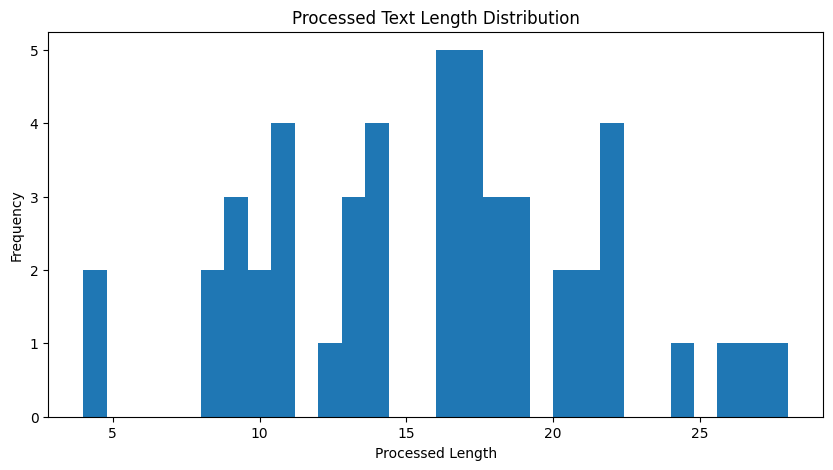

TF-IDF Vectorization Completed!

Shape of TF-IDF Matrix:
(49, 83)

First 20 Features:

['angry' 'anxious' 'anymore' 'awake' 'better' 'burned' 'cant' 'confused'
 'connection' 'constantly' 'control' 'cope' 'cry' 'day' 'dont' 'empty'
 'enough' 'everyone' 'exhausted' 'exploding']

TF-IDF DataFrame Created Successfully!

TF-IDF DataFrame Shape:
(49, 83)

TF-IDF Sample:

   angry   anxious   anymore  awake  better  burned      cant  confused  \
0    0.0  0.000000  0.000000    0.0     0.0     0.0  0.000000       0.0   
1    0.0  0.000000  0.000000    0.0     0.0     0.0  0.481026       0.0   
2    0.0  0.000000  0.000000    0.0     0.0     0.0  0.000000       0.0   
3    0.0  0.000000  0.445721    0.0     0.0     0.0  0.000000       0.0   
4    0.0  0.901807  0.000000    0.0     0.0     0.0  0.000000       0.0   

   connection  constantly  ...  tired     today  uncertain  understands  wake  \
0         0.0         0.0  ...    0.0  0.631823        0.0          0.0   0.0   
1         0.0      

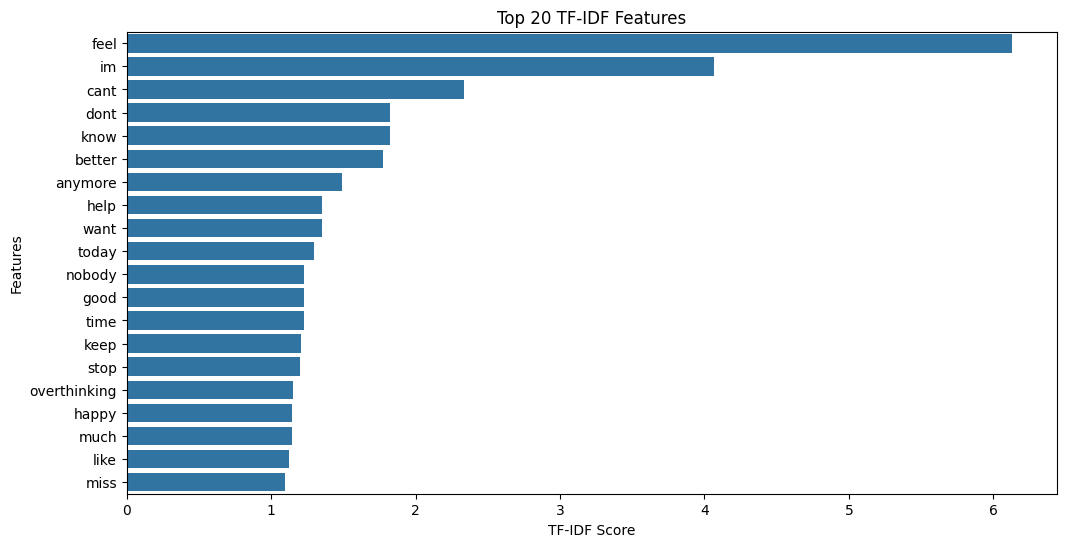

TF-IDF Vectorizer saved successfully!

TF-IDF Matrix Saved Successfully!
Processed dataset saved successfully!

PHASE 3 COMPLETED SUCCESSFULLY

Final Dataset Shape: (49, 6)

Tasks Completed:
1. Dataset Loaded
2. NLP Preprocessing Pipeline Created
3. Lowercasing Applied
4. Punctuation Removed
5. URLs Removed
6. Numbers Removed
7. Stopwords Removed
8. Lemmatization Applied
9. TF-IDF Vectorization Completed
10. Vectorizer Saved
11. Processed Dataset Saved


In [ ]:
print ('Phase 3 --> NLP Precessing \n')
#import libraries
import pandas as pd
import numpy as np
import re
import string
import nltk
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

#download nltk resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
print("NLTK resources downloaded successfully!")

#load dataset
df = pd.read_csv("../data/eda_processed_dataset.csv")
print("Dataset loaded successfully!")

#initialize NLP tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
print("NLP tools initialized successfully!")

#NLP(natural language processing)

def preprocess_text(text):

# convert to string
    text = str(text)

#lowercase
    text = text.lower()

#remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

#remove numbers
    text = re.sub(r'\d+', '', text)

#remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

#remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

#remove extra spaces
    text = text.strip()

#tokenization
    tokens = word_tokenize(text)

#stopwords removal
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]
#lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
#join words
    cleaned_text = " ".join(tokens)
    return cleaned_text

#apply processing
df['processed_text'] = df['text'].apply(
    preprocess_text
)
print("Text preprocessing completed successfully!")

#original vs processed text
for i in range(5):
    print("\n================================================")
    print("ORIGINAL TEXT:\n")
    print(df['text'].iloc[i])
    print("\nPROCESSED TEXT:\n")
    print(df['processed_text'].iloc[i])

#empty text check
empty_rows = df[
    df['processed_text'].str.len() == 0
]
print("Number of Empty Processed Rows:")
print(len(empty_rows))

#remove empty rows
df = df[
    df['processed_text'].str.len() > 0
]

#processed text length
print('Processed Text Length:')
df['processed_length'] = df['processed_text'].apply(len)
print(df['processed_length'].describe())

#visualization
plt.figure(figsize=(10, 5))
plt.hist(df['processed_length'], bins=30)
plt.title("Processed Text Length Distribution")
plt.xlabel("Processed Length")
plt.ylabel("Frequency")
plt.show()

#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000
)
X = vectorizer.fit_transform(
    df['processed_text']
)
print("TF-IDF Vectorization Completed!")
print("\nShape of TF-IDF Matrix:")
print(X.shape)

#feature names
feature_names = vectorizer.get_feature_names_out()
print("\nFirst 20 Features:\n")
print(feature_names[:20])

#convert TF-IDF to data frame
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=feature_names
)
print("\nTF-IDF DataFrame Created Successfully!")
print("\nTF-IDF DataFrame Shape:")
print(tfidf_df.shape)

#disply TF-IDF sample
print("\nTF-IDF Sample:\n")
print(tfidf_df.head())

#top TF-IDF features
feature_sums = np.array(X.sum(axis=0)).flatten()
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Score': feature_sums
})
top_features = feature_importance.sort_values(
    by='Score',
    ascending=False
).head(20)
print("\nTop 20 Important TF-IDF Features:\n")
print(top_features)

#top TF-IDF visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Score',
    y='Feature',
    data=top_features
)
plt.title("Top 20 TF-IDF Features")
plt.xlabel("TF-IDF Score")
plt.ylabel("Features")
plt.show()

#save TF-IDF vectorizer
with open('../models/tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)
print("TF-IDF Vectorizer saved successfully!")

#save TD-IDF matrix
with open('../models/tfidf_features.pkl', 'wb') as file:
    pickle.dump(X, file)
print("\nTF-IDF Matrix Saved Successfully!")

#save processed dataset
df.to_csv(
    "../data/final_processed_dataset.csv",
    index=False
)
print("Processed dataset saved successfully!")

# ============================================================
# STEP 30 — FINAL SUMMARY
# ============================================================

print("\n===================================================")
print("PHASE 3 COMPLETED SUCCESSFULLY")
print("===================================================")

print(f"\nFinal Dataset Shape: {df.shape}")

print("\nTasks Completed:")
print("1. Dataset Loaded")
print("2. NLP Preprocessing Pipeline Created")
print("3. Lowercasing Applied")
print("4. Punctuation Removed")
print("5. URLs Removed")
print("6. Numbers Removed")
print("7. Stopwords Removed")
print("8. Lemmatization Applied")
print("9. TF-IDF Vectorization Completed")
print("10. Vectorizer Saved")
print("11. Processed Dataset Saved")